probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

# Set up

In [2]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [1]:
# Load full group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [3]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set_theme()

In [9]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.1
V1 = Allen_dataset(fps=1000,
               start_time=start_time, 
               end_time=end_time,
               padding=padding,
#                    orientation=[0],
               session_id=757216464,
               selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
#                stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
               stimulus_condition_id = [246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258,
                                       259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 271,
                                       272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284,
                                       285, 286, 270],
               stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [10]:
membership[0]

,probe,group_id
unit_ids,,
951814834,probeA,2
951814827,probeA,1
951814874,probeA,2
951814839,probeA,1
951814898,probeA,1
...,...,...
951804296,probeF,2
951804325,probeF,2
951804346,probeF,2


In [11]:
condition_ids

[246,
 247,
 248,
 249,
 250,
 251,
 252,
 253,
 255,
 256,
 257,
 258,
 259,
 260,
 261,
 262,
 263,
 264,
 265,
 266,
 267,
 268,
 269,
 271,
 272,
 273,
 274,
 275,
 276,
 277,
 278,
 279,
 280,
 281,
 282,
 283,
 284,
 285,
 286,
 270]

# probeA 

## Use group_id

Negative log likelihood is: 99825.67
aic/2 is: 99856.67
Negative log likelihood is: 83472.87
aic/2 is: 83503.87


/home/qix/MultiNeuronGLM/utility_functions.py:285: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-ci)), np.exp((y+ci)), color=color, alpha=.3)
/home/qix/MultiNeuronGLM/utility_functions.py:285: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-ci)), np.exp((y+ci)), color=color, alpha=.3)


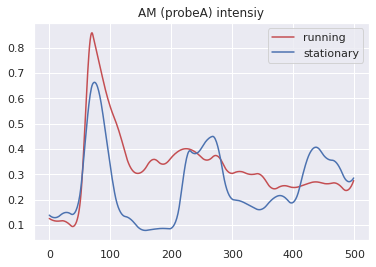

In [21]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeA', verbose=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeA', verbose=True))

label_list = ['running', 'stationary']

title_list = ['AM (probeA) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

## use all neurons

Negative log likelihood is: 129605.19
aic/2 is: 129636.19
Negative log likelihood is: 116695.62
aic/2 is: 116726.62


/home/qix/MultiNeuronGLM/utility_functions.py:285: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-ci)), np.exp((y+ci)), color=color, alpha=.3)


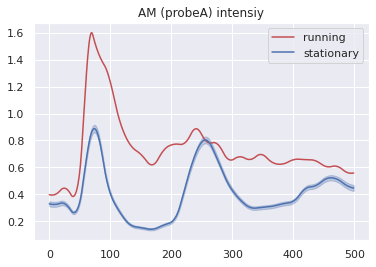

In [25]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeA', verbose=True, use_all=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeA', verbose=True, use_all=True))

label_list = ['running', 'stationary']

title_list = ['AM (probeA) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

# probeB

## Use group_id

Negative log likelihood is: 84453.23
aic/2 is: 84484.23
Negative log likelihood is: 62280.82
aic/2 is: 62311.82


/home/qix/MultiNeuronGLM/utility_functions.py:285: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-ci)), np.exp((y+ci)), color=color, alpha=.3)


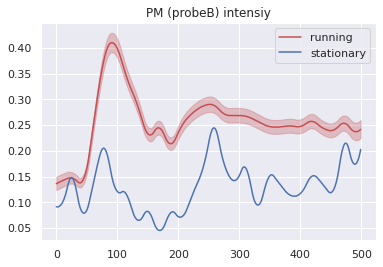

In [26]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeB', verbose=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeB', verbose=True))

label_list = ['running', 'stationary']

title_list = ['PM (probeB) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

## Use all neurons

Negative log likelihood is: 105878.59
aic/2 is: 105909.59
Negative log likelihood is: 88936.07
aic/2 is: 88967.07


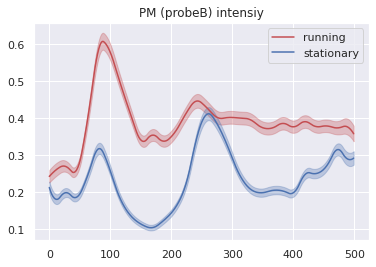

In [27]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeB', verbose=True, use_all=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeB', verbose=True, use_all=True))

label_list = ['running', 'stationary']

title_list = ['PM (probeB) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

# probeC

## Use group_id

Negative log likelihood is: 100390.90
aic/2 is: 100421.90
Negative log likelihood is: 92402.17
aic/2 is: 92433.17


/home/qix/MultiNeuronGLM/utility_functions.py:285: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-ci)), np.exp((y+ci)), color=color, alpha=.3)
/home/qix/MultiNeuronGLM/utility_functions.py:285: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-ci)), np.exp((y+ci)), color=color, alpha=.3)


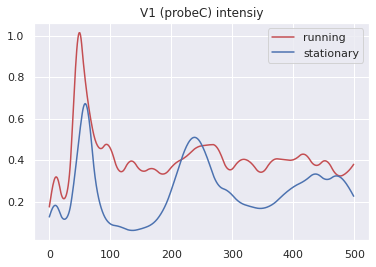

In [28]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeC', verbose=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeC', verbose=True))

label_list = ['running', 'stationary']

title_list = ['V1 (probeC) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

## Use all neurons

Negative log likelihood is: 120832.85
aic/2 is: 120863.85
Negative log likelihood is: 114353.23
aic/2 is: 114384.23


/home/qix/MultiNeuronGLM/utility_functions.py:285: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-ci)), np.exp((y+ci)), color=color, alpha=.3)


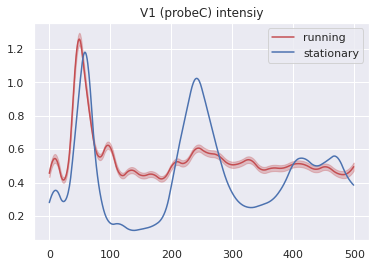

In [29]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeC', verbose=True, use_all=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeC', verbose=True, use_all=True))

label_list = ['running', 'stationary']

title_list = ['V1 (probeC) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

# probeD

## Use group_id

Negative log likelihood is: 84581.22
aic/2 is: 84612.22
Negative log likelihood is: 67300.16
aic/2 is: 67331.16


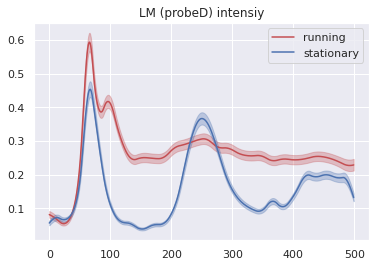

In [30]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeD', verbose=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeD', verbose=True))

label_list = ['running', 'stationary']

title_list = ['LM (probeD) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

## Use all neurons

Negative log likelihood is: 105281.10
aic/2 is: 105312.10
Negative log likelihood is: 86503.10
aic/2 is: 86534.10


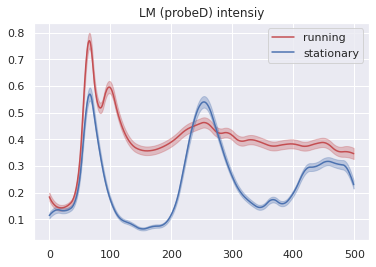

In [31]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeD', verbose=True, use_all=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeD', verbose=True, use_all=True))

label_list = ['running', 'stationary']

title_list = ['LM (probeD) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

# probeE

## Use group_id

Negative log likelihood is: 95348.81
aic/2 is: 95379.81
Negative log likelihood is: 76206.30
aic/2 is: 76237.30


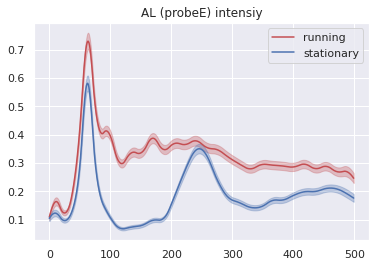

In [32]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeE', verbose=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeE', verbose=True))

label_list = ['running', 'stationary']

title_list = ['AL (probeE) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

## Use all neurons

Negative log likelihood is: 124246.14
aic/2 is: 124277.14
Negative log likelihood is: 110189.03
aic/2 is: 110220.03


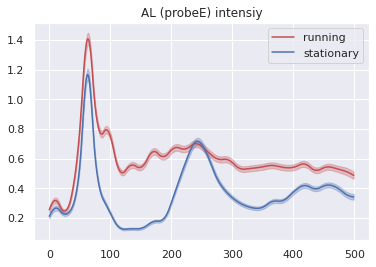

In [33]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeE', verbose=True, use_all=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeE', verbose=True, use_all=True))

label_list = ['running', 'stationary']

title_list = ['AL (probeE) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

# probeF

## Use group_id

Negative log likelihood is: 67863.29
aic/2 is: 67884.29
Negative log likelihood is: 42284.77
aic/2 is: 42305.77


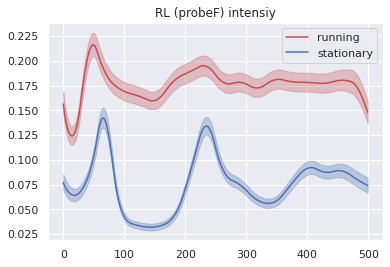

In [36]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 20

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeF', verbose=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeF', verbose=True))

label_list = ['running', 'stationary']

title_list = ['RL (probeF) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)

## Use all neurons

Negative log likelihood is: 88047.72
aic/2 is: 88068.72
Negative log likelihood is: 62074.40
aic/2 is: 62095.40


/home/qix/MultiNeuronGLM/utility_functions.py:285: RuntimeWarning: overflow encountered in exp
  plt.fill_between(x, np.exp((y-ci)), np.exp((y+ci)), color=color, alpha=.3)


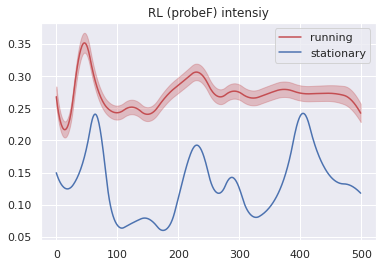

In [37]:
results_list = []

best_time_diff = 0
smooth_std = 20
num_basis_baseline = 20

select_trials = V1.running_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
# model.add_effect('coupling', 'probeD', peaks_max=200, num=5, nonlinear=1, verbose=False)
results_list.append(model.fit('probeF', verbose=True, use_all=True))

select_trials = V1.stationary_trial_index
model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
results_list.append(model.fit('probeF', verbose=True, use_all=True))

label_list = ['running', 'stationary']

title_list = ['RL (probeF) intensiy']
GLM.plot_GLM_compare(model, results_list=results_list, label_list=label_list, 
                    title_list=title_list)